# 🌞 Next-Day Solar Irradiance Forecasting with RNN and LSTM
### Deep Learning Assignment — RUET, Department of CSE
**Location:** Rajshahi, Bangladesh (24.3641°N, 88.63°E) | **Data:** NASA POWER daily data, 2011–2025
**Task:** Regression — predict tomorrow's Global Horizontal Irradiance, GHI(t+1), from the last few days of weather.

---
### How this notebook is organised (it follows the assignment instructions)
| Section | What it does | Assignment item |
|---|---|---|
| 1–2 | Setup, upload and clean the data | Dataset |
| 3 | Exploratory plots | Dataset understanding |
| 4 | Preprocessing, 60/20/20 split, windows | Dataset |
| 5 | Model choice and architecture | **1. Model Selection & Architecture** |
| 6 | Forward pass, backpropagation, Adam (maths) | **2. Mathematical Explanation** |
| 7 | Training RNN and LSTM | **3. Regularization & Tuning** |
| 8 | Loss curves, metrics, prediction plots | **4. Performance Evaluation** |
| 9 | Ablation: effect of L2 / dropout / LR scheduling | **3. Analyse their impact** |
| 10 | Vanishing / exploding gradient + RNN vs LSTM | **5. Critical Analysis** |
| 11 | Real-life application | **6. Application Perspective** |
| 12 | Summary tables + download all figures | Report |

**How to run:** `Runtime → Run all`. When the upload cell appears, choose the NASA POWER CSV file.
Everything is saved to a `figures/` folder; the last cell downloads it as a zip so you can paste the figures into your report.

## 📦 Section 1: Setup and Settings

In [27]:
import os, io, random, time, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
print('TensorFlow version:', tf.__version__)
print('GPU available     :', len(tf.config.list_physical_devices('GPU')) > 0)

# ---- Reproducibility: the same seed gives (nearly) the same results every run
SEED = 42
def set_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_seed()

# ---- Plot style + helper that saves every figure into the 'figures' folder
os.makedirs('figures', exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 300, 'axes.titlesize': 12, 'axes.labelsize': 11})
PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']
C_RNN, C_LSTM, C_TRUE = '#d62728', '#1f77b4', 'black'

def save_fig(name):
    plt.savefig(f'figures/{name}.png', dpi=300, bbox_inches='tight')

TensorFlow version: 2.21.0
GPU available     : True


### ⚙️ All hyperparameters in one place
Change values here if you want to experiment. These same values are printed in the report table in Section 12.

In [28]:
# ----- Data -----
WINDOW      = 14      # how many past days the network looks at
TRAIN_FRAC  = 0.60    # 60 % train
VAL_FRAC    = 0.20    # 20 % validation  (next 20 %)  -> remaining 20 % = test

# ----- Model -----
UNITS_1     = 64      # neurons in recurrent layer 1
UNITS_2     = 32      # neurons in recurrent layer 2
DENSE_UNITS = 16      # neurons in the dense layer before the output
DROPOUT     = 0.2     # regularization 1: dropout rate
L2_LAMBDA   = 1e-4    # regularization 2: L2 strength

# ----- Training -----
LR          = 1e-3    # initial learning rate (Adam)
BATCH_SIZE  = 32
MAX_EPOCHS  = 100     # upper limit; early stopping usually stops earlier
CLIPNORM    = 1.0     # gradient clipping (protects against exploding gradients)

# ----- Learning-rate scheduler (ReduceLROnPlateau) -----
LR_FACTOR   = 0.5     # new_lr = old_lr * 0.5
LR_PATIENCE = 5       # wait 5 epochs without improvement
MIN_LR      = 1e-5

# ----- Early stopping -----
ES_PATIENCE = 15      # stop if validation loss does not improve for 15 epochs

# ----- Run time -----
# The main RNN/LSTM training takes a few minutes. Sections 9 and 10 train many extra models.
# If Colab feels slow, set QUICK_RUN = True (shorter ablation, windows of 7 and 30 days only),
# or use  Runtime -> Change runtime type -> T4 GPU.
QUICK_RUN   = False

## 📂 Section 2: Upload and Clean the Dataset

In [29]:
# Upload your NASA POWER CSV directly from your computer.
# A 'Choose Files' button will appear — select the CSV file.
from google.colab import files

uploaded  = files.upload()
filename  = list(uploaded.keys())[0]
raw_bytes = io.BytesIO(uploaded[filename])

# Auto-detect the NASA POWER header row (line starting with 'YEAR')
header_row = None
raw_bytes.seek(0)
for idx, line in enumerate(raw_bytes):
    if line.decode('utf-8').startswith('YEAR'):
        header_row = idx
        break

# Load CSV, skipping NASA metadata lines above the column header
raw_bytes.seek(0)
df_raw = pd.read_csv(raw_bytes, skiprows=header_row)

print(f'✓ Loaded : {filename}')
print(f'  Shape  : {df_raw.shape}')
display(df_raw.head())

Saving POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC.csv to POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC (1).csv
✓ Loaded : POWER_Point_Daily_20110101_20251231_024d36N_088d63E_UTC (1).csv
  Shape  : (5479, 8)


,YEAR,MO,DY,ALLSKY_SFC_SW_DWN,WS2M,T2M,RH2M,PRECTOTCORR
0,2011,1,1,2.0246,1.25,16.43,78.82,0.49
1,2011,1,2,3.5866,1.77,14.99,56.22,0.00
2,2011,1,3,3.1910,1.52,14.70,61.12,0.00
3,2011,1,4,3.2753,2.10,14.79,67.34,0.00
4,2011,1,5,3.4990,1.99,14.41,62.50,0.00


In [30]:
# Build a date index and give the columns readable names
df = df_raw.copy()
df['Date'] = pd.to_datetime(
    df[['YEAR', 'MO', 'DY']].rename(columns={'YEAR': 'year', 'MO': 'month', 'DY': 'day'})
)
df = df.drop(columns=['YEAR', 'MO', 'DY']).set_index('Date').sort_index()
df = df.rename(columns={
    'ALLSKY_SFC_SW_DWN': 'GHI',          # solar irradiance (kWh/m^2/day)  <- our target
    'T2M'              : 'Temperature',  # deg C
    'RH2M'             : 'Humidity',     # %
    'WS2M'             : 'WindSpeed',    # m/s
    'PRECTOTCORR'      : 'Precipitation' # mm/day
})

# NASA uses -999 for missing values -> turn into NaN and fill by linear interpolation
cols = ['GHI', 'Temperature', 'Humidity', 'WindSpeed', 'Precipitation']
print('Missing values (-999) per column:')
print((df[cols] == -999).sum().to_string())
df[cols] = df[cols].replace(-999, np.nan).interpolate(method='linear').bfill().ffill()

print(f'\nDate range : {df.index[0].date()} -> {df.index[-1].date()}')
print(f'Total days : {len(df)}')
print(f'Any NaN left? {df.isna().any().any()}')
display(df.describe().T.round(3))

Missing values (-999) per column:
GHI              0
Temperature      0
Humidity         0
WindSpeed        0
Precipitation    0

Date range : 2011-01-01 -> 2025-12-31
Total days : 5479
Any NaN left? False


,count,mean,std,min,25%,50%,75%,max
GHI,5479.0,4.398,1.268,0.529,3.524,4.428,5.329,7.547
WindSpeed,5479.0,1.855,0.839,0.250,1.250,1.650,2.290,9.250
Temperature,5479.0,25.635,5.304,9.930,21.510,27.710,29.360,36.770
Humidity,5479.0,70.565,18.000,12.790,57.875,76.440,85.265,95.280
Precipitation,5479.0,4.289,8.345,0.000,0.000,0.490,5.070,90.240


## 🔍 Section 3: Exploratory Data Analysis (EDA)

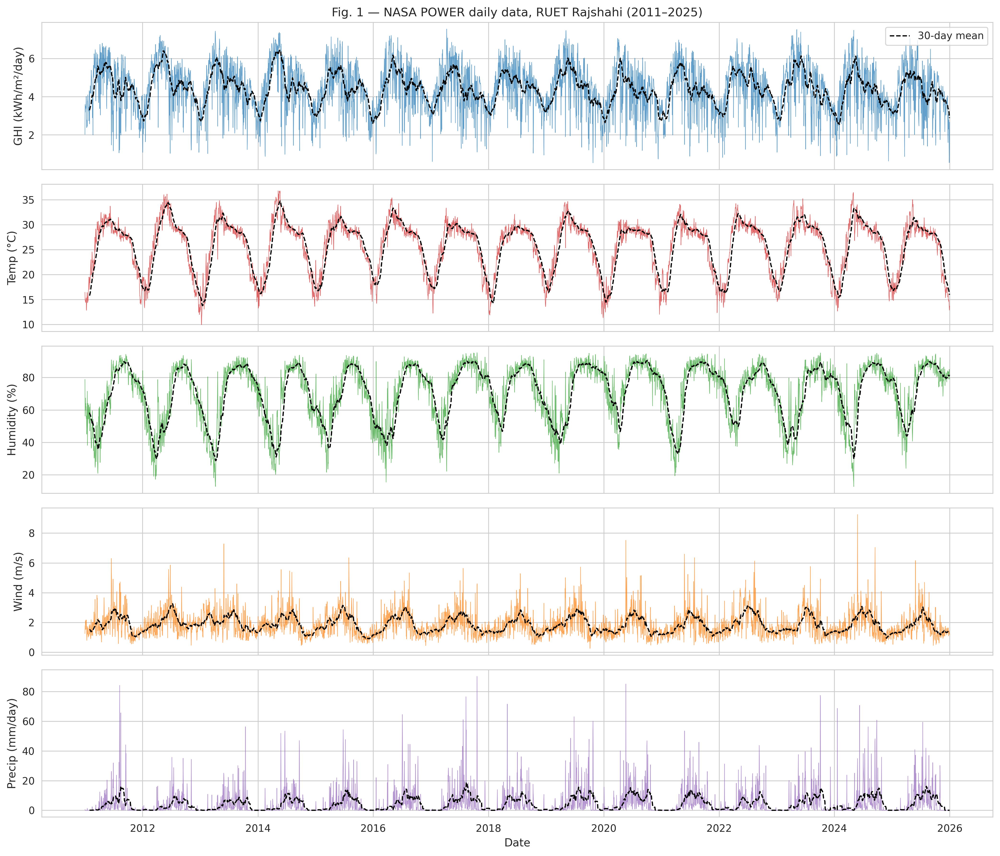

In [31]:
# Figure 1 - the whole time series (grey = daily value, black dashed = 30-day average)
ylabels = ['GHI (kWh/m²/day)', 'Temp (°C)', 'Humidity (%)', 'Wind (m/s)', 'Precip (mm/day)']
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
for ax, col, yl, c in zip(axes, cols, ylabels, PALETTE):
    ax.plot(df.index, df[col], color=c, lw=0.5, alpha=0.7)
    ax.plot(df.index, df[col].rolling(30).mean(), color='black', lw=1.2, ls='--', label='30-day mean')
    ax.set_ylabel(yl)
axes[0].legend(loc='upper right')
axes[0].set_title('Fig. 1 — NASA POWER daily data, RUET Rajshahi (2011–2025)')
axes[-1].set_xlabel('Date')
plt.tight_layout(); save_fig('fig01_timeseries'); plt.show()

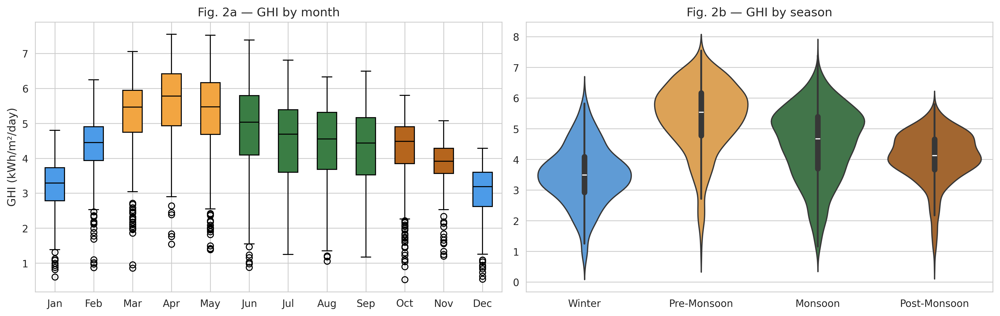

In [32]:
# Figure 2 - GHI by month (shows the strong yearly cycle and the monsoon dip)
def get_season(m):
    if m in [12, 1, 2]:   return 'Winter'
    if m in [3, 4, 5]:    return 'Pre-Monsoon'
    if m in [6, 7, 8, 9]: return 'Monsoon'
    return 'Post-Monsoon'
SEASONS = ['Winter', 'Pre-Monsoon', 'Monsoon', 'Post-Monsoon']
SEASON_COLORS = dict(zip(SEASONS, ['#4c9be8', '#f2a541', '#3a7d44', '#b5651d']))

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
data_m = [df[df.index.month == m]['GHI'].values for m in range(1, 13)]
bp = axes[0].boxplot(data_m, labels=months, patch_artist=True, medianprops=dict(color='black'))
for patch, m in zip(bp['boxes'], range(1, 13)):
    patch.set_facecolor(SEASON_COLORS[get_season(m)])
axes[0].set_title('Fig. 2a — GHI by month'); axes[0].set_ylabel('GHI (kWh/m²/day)')

season_series = df.index.month.map(get_season)
sns.violinplot(x=pd.Categorical(season_series, SEASONS), y=df['GHI'].values,
               palette=SEASON_COLORS, ax=axes[1])
axes[1].set_title('Fig. 2b — GHI by season'); axes[1].set_xlabel(''); axes[1].set_ylabel('')
plt.tight_layout(); save_fig('fig02_monthly_seasonal'); plt.show()

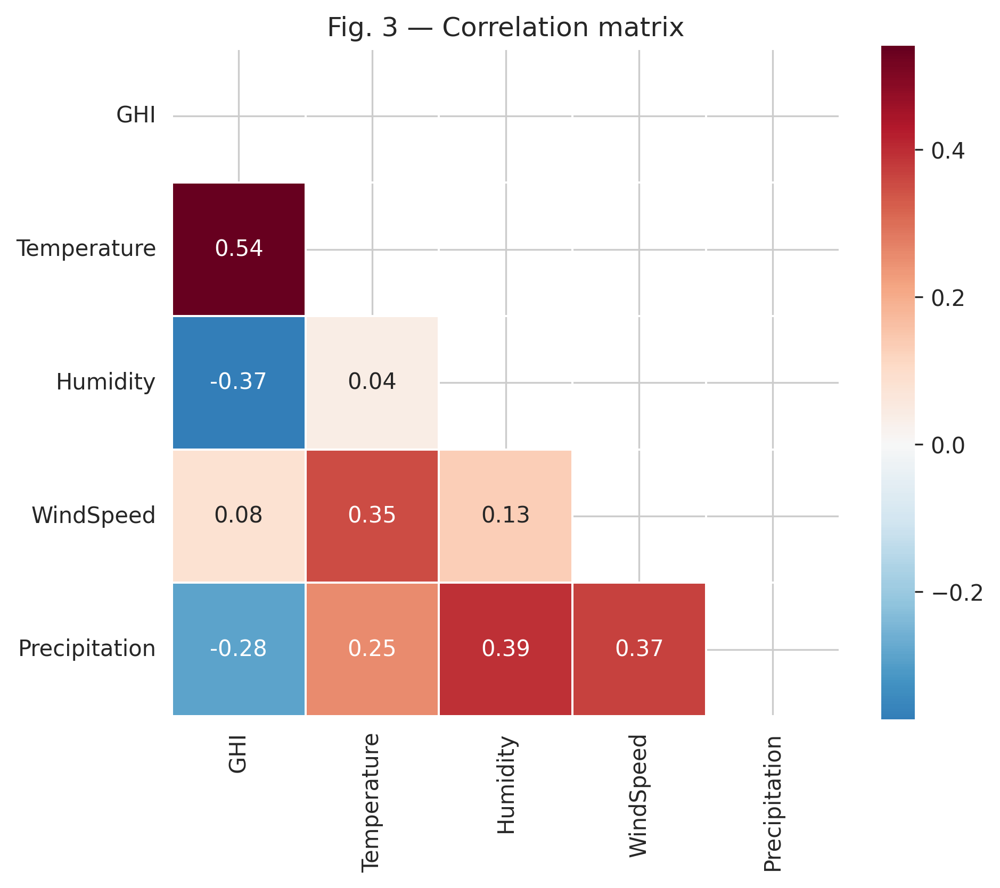

In [33]:
# Figure 3 - correlation between variables
corr = df[cols].corr()
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            mask=np.triu(np.ones_like(corr, dtype=bool)), linewidths=0.5)
plt.title('Fig. 3 — Correlation matrix')
plt.tight_layout(); save_fig('fig03_correlation'); plt.show()

## 🧱 Section 4: Preprocessing, Data Split and Sliding Windows

**1. Features.** We use the 5 weather variables plus two "calendar" features, `sin_doy` and `cos_doy`.
They turn the day of the year (1–365) into a circle, so that 31 Dec and 1 Jan are close neighbours. Without this, the network would think they are far apart.

**2. Target.** GHI of the *next* day.

**3. Split (60 / 20 / 20, in time order).** Important: for time series we **never shuffle** before splitting.
If we did, the model would train on days that come *after* the days it is tested on — that is cheating (data leakage).
* Train 60 % → early years (learns the patterns)
* Validation 20 % → next years (used to tune settings, decide when to stop and when to lower the learning rate)
* Test 20 % → the last years (touched only once, at the end, for the final honest score)

Your plan (80/20 split, then 20 % of the training part for validation) gives: 0.8 × 0.8 = **64 %** train, 16 % validation, 20 % test.
The 60/20/20 split used here is almost the same, and it has a neat property: with 5 479 days it splits exactly into whole years — train 2011–2019, validation 2020–2022, test 2023–2025.

**4. Scaling.** Neural networks train better when inputs are on a similar scale. We standardise each feature (mean 0, std 1) using **only the training rows**, so no information from validation/test leaks in.

**5. Sliding window.** One sample = the last `WINDOW` days of all features → predict GHI of the day after.

In [34]:
# ---- Features: weather + cyclic day-of-year
feat = df[cols].copy()
doy = df.index.dayofyear.values
feat['sin_doy'] = np.sin(2 * np.pi * doy / 365.25)
feat['cos_doy'] = np.cos(2 * np.pi * doy / 365.25)
FEATURES = list(feat.columns)
N_FEATURES = len(FEATURES)
print('Features used:', FEATURES)

# ---- Chronological split points (by day index)
N = len(df)
train_end = int(TRAIN_FRAC * N)                 # days [0, train_end)           -> train
val_end   = int((TRAIN_FRAC + VAL_FRAC) * N)    # days [train_end, val_end)     -> validation
                                                # days [val_end, N)             -> test
print(f'Train : {df.index[0].date()} -> {df.index[train_end-1].date()}  ({train_end} days)')
print(f'Val   : {df.index[train_end].date()} -> {df.index[val_end-1].date()}  ({val_end-train_end} days)')
print(f'Test  : {df.index[val_end].date()} -> {df.index[-1].date()}  ({N-val_end} days)')

# ---- Scaling (fit on TRAIN rows only)
x_scaler = StandardScaler().fit(feat.iloc[:train_end])
y_scaler = StandardScaler().fit(df[['GHI']].iloc[:train_end])
feat_scaled = x_scaler.transform(feat).astype('float32')
ghi_scaled  = y_scaler.transform(df[['GHI']]).ravel().astype('float32')
ghi_raw     = df['GHI'].values

# ---- Sliding windows
def make_windows(window):
    """Return X (samples, window, features) and the day index of each target."""
    idx = np.arange(window, N)
    X = np.stack([feat_scaled[i - window:i] for i in idx])
    y = ghi_scaled[idx]
    return X, y, idx

def split_windows(window):
    X, y, idx = make_windows(window)
    tr, va, te = idx < train_end, (idx >= train_end) & (idx < val_end), idx >= val_end
    return {'train': (X[tr], y[tr], idx[tr]),
            'val'  : (X[va], y[va], idx[va]),
            'test' : (X[te], y[te], idx[te])}

data = split_windows(WINDOW)
X_train, y_train, idx_train = data['train']
X_val,   y_val,   idx_val   = data['val']
X_test,  y_test,  idx_test  = data['test']
for name, (X_, y_, _) in data.items():
    print(f'{name:5s}: X shape = {X_.shape}   y shape = {y_.shape}')
print(f'\nEach sample = {WINDOW} days x {N_FEATURES} features  ->  predicts GHI of the following day')

Features used: ['GHI', 'Temperature', 'Humidity', 'WindSpeed', 'Precipitation', 'sin_doy', 'cos_doy']
Train : 2011-01-01 -> 2019-12-31  (3287 days)
Val   : 2020-01-01 -> 2022-12-31  (1096 days)
Test  : 2023-01-01 -> 2025-12-31  (1096 days)
train: X shape = (3273, 14, 7)   y shape = (3273,)
val  : X shape = (1096, 14, 7)   y shape = (1096,)
test : X shape = (1096, 14, 7)   y shape = (1096,)

Each sample = 14 days x 7 features  ->  predicts GHI of the following day


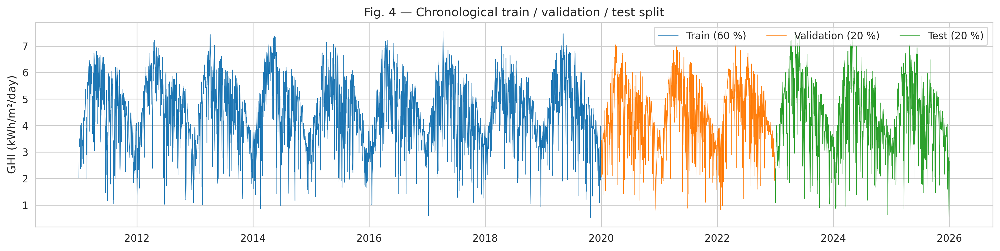

In [35]:
# Figure 4 - show the chronological split
plt.figure(figsize=(14, 3.6))
for lo, hi, name, c in [(0, train_end, 'Train (60 %)', '#1f77b4'),
                        (train_end, val_end, 'Validation (20 %)', '#ff7f0e'),
                        (val_end, N, 'Test (20 %)', '#2ca02c')]:
    plt.plot(df.index[lo:hi], df['GHI'].iloc[lo:hi], color=c, lw=0.6, label=name)
plt.ylabel('GHI (kWh/m²/day)'); plt.legend(loc='upper right', ncol=3)
plt.title('Fig. 4 — Chronological train / validation / test split')
plt.tight_layout(); save_fig('fig04_split'); plt.show()

## 🏗️ Section 5: Model Selection and Architecture

### Why recurrent networks (RNN / LSTM)?
Solar irradiance is a **time series**: tomorrow depends on the last few days (cloud systems persist, the monsoon builds up slowly).
A normal MLP treats the inputs as an unordered list, while a recurrent network reads the days **one after another** and keeps a memory (the *hidden state*) of what it has seen. That is why RNN-type models are a natural choice here. (A CNN could also work, but it is less natural for sequential memory.)

* **Simple RNN** — the basic recurrent cell. Easy, but its memory fades quickly (vanishing gradient problem).
* **LSTM** — adds *gates* and a separate *cell state* so it can keep important information for many steps. We expect it to handle longer windows better.

### Architecture (identical for both models, only the recurrent cell changes)
| Layer | Output shape | Details |
|---|---|---|
| Input | (14, 7) | 14 days × 7 features |
| Recurrent layer 1 | (14, 64) | RNN or LSTM, `tanh` activation, L2 on weights, returns the whole sequence |
| Dropout | (14, 64) | rate 0.2 |
| Recurrent layer 2 | (32) | RNN or LSTM, `tanh` activation, L2 on weights, returns only the last state |
| Dropout | (32) | rate 0.2 |
| Dense | (16) | `ReLU`, L2 |
| Output Dense | (1) | **linear** (no activation) → predicted GHI (scaled) |

**Output formulation:** this is regression, so the last neuron is linear and the loss is Mean Squared Error (MSE). For classification we would use softmax/sigmoid instead.

In [36]:
def build_model(kind, window=WINDOW, dropout=DROPOUT, l2=L2_LAMBDA, name=None):
    """kind = 'RNN' or 'LSTM'. Same structure for both so the comparison is fair."""
    Cell = layers.SimpleRNN if kind == 'RNN' else layers.LSTM
    reg = regularizers.l2(l2) if l2 > 0 else None
    model = keras.Sequential(name=name or kind, layers=[
        layers.Input(shape=(window, N_FEATURES)),
        Cell(UNITS_1, return_sequences=True, kernel_regularizer=reg, recurrent_regularizer=reg),
        layers.Dropout(dropout),
        Cell(UNITS_2, kernel_regularizer=reg, recurrent_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(DENSE_UNITS, activation='relu', kernel_regularizer=reg),
        layers.Dense(1)                                   # linear output
    ])
    return model

rnn_demo, lstm_demo = build_model('RNN'), build_model('LSTM')
rnn_demo.summary()
lstm_demo.summary()
print(f'\nTrainable parameters -> RNN: {rnn_demo.count_params():,} | LSTM: {lstm_demo.count_params():,}')
print('(An LSTM has about 4x more weights per unit than an RNN, because of its 4 internal gates/transformations.)')

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 14, 64)         │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,257 (32.25 KB)

 Trainable params: 8,257 (32.25 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 14, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters -> RNN: 8,257 | LSTM: 31,393
(An LSTM has about 4x more weights per unit than an RNN, because of its 4 internal gates/transformations.)


## 🧮 Section 6: Mathematical Explanation

Notation: $x_t$ = input vector on day $t$, $h_t$ = hidden state, $\hat y$ = prediction, $y$ = true value, $\sigma$ = sigmoid, $\odot$ = element-wise product.

### 6.1 Forward pass
**Simple RNN** (one step):
$$h_t = \tanh\!\big(W x_t + U h_{t-1} + b\big)$$

**LSTM** (one step):
$$f_t=\sigma(W_f x_t+U_f h_{t-1}+b_f)\qquad\text{(forget gate: what to erase)}$$
$$i_t=\sigma(W_i x_t+U_i h_{t-1}+b_i)\qquad\text{(input gate: what to write)}$$
$$\tilde c_t=\tanh(W_c x_t+U_c h_{t-1}+b_c)\qquad\text{(candidate memory)}$$
$$c_t=f_t\odot c_{t-1}+i_t\odot \tilde c_t\qquad\text{(cell state update)}$$
$$o_t=\sigma(W_o x_t+U_o h_{t-1}+b_o)\qquad\text{(output gate)}$$
$$h_t=o_t\odot\tanh(c_t)$$

After the last day $T$ the final hidden state goes through the Dense layers; the last (linear) neuron gives $\hat y = w^\top a + b$.

### 6.2 Loss function (MSE + L2)
$$L=\underbrace{\frac1N\sum_{n=1}^{N}(y_n-\hat y_n)^2}_{\text{prediction error}}+\underbrace{\lambda\sum_j \theta_j^2}_{\text{L2 penalty}}$$
The L2 term punishes large weights, which keeps the model smoother and reduces over-fitting. $\lambda$ = `L2_LAMBDA`.

### 6.3 Backpropagation Through Time (BPTT)
The network is "unrolled" over the $T$ days and the chain rule is applied backwards. The gradient reaching an early day $k$ is a **product** of one-step Jacobians:
$$\frac{\partial L}{\partial h_k}=\frac{\partial L}{\partial h_T}\prod_{t=k+1}^{T}\frac{\partial h_t}{\partial h_{t-1}}$$
* **RNN:** $\dfrac{\partial h_t}{\partial h_{t-1}}=\mathrm{diag}(1-h_t^2)\,U$. Repeatedly multiplying by this matrix makes the gradient shrink roughly like $(\gamma\|U\|)^{T-k}$:
  if this factor is $<1$ the gradient **vanishes** (early days are forgotten), if $>1$ it **explodes** (unstable training).
* **LSTM:** the cell state is updated additively, so $\dfrac{\partial c_t}{\partial c_{t-1}}\approx f_t$. When the forget gate is near 1 the gradient flows almost unchanged through many steps — this is the "constant error carousel" that helps with vanishing gradients.

### 6.4 Weight update with Adam
With gradient $g_t=\nabla_\theta L$ (this already includes the L2 term $2\lambda\theta$), Adam keeps running averages of the gradient and of its square:
$$m_t=\beta_1 m_{t-1}+(1-\beta_1)g_t,\qquad v_t=\beta_2 v_{t-1}+(1-\beta_2)g_t^2$$
$$\hat m_t=\frac{m_t}{1-\beta_1^t},\quad \hat v_t=\frac{v_t}{1-\beta_2^t},\qquad \theta_{t+1}=\theta_t-\eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}$$
Defaults: $\beta_1=0.9,\ \beta_2=0.999,\ \varepsilon=10^{-7}$, and $\eta$ = learning rate (here 0.001, lowered by the scheduler).
Compared with plain gradient descent ($\theta\leftarrow\theta-\eta g$), Adam gives every weight its own step size, which is why it works well out-of-the-box for recurrent networks.

**Why Adam?** It is fast, needs little tuning, and copes with noisy gradients. We add **gradient clipping** (`clipnorm`): if the total gradient length $\|g\|$ is larger than $c$ (=1.0), it is rescaled to $g\leftarrow g\cdot c/\|g\|$. This protects against exploding gradients.

### 6.5 Learning-rate scheduling
`ReduceLROnPlateau`: if the validation loss does not improve for 5 epochs, the learning rate is halved. Large steps early on give fast progress; small steps later give fine, stable convergence.

## 🏋️ Section 7: Training the RNN and the LSTM

**Regularization used (3 techniques, to prevent over-fitting):**
1. **L2 weight penalty** (`L2_LAMBDA = 1e-4`)
2. **Dropout** (`DROPOUT = 0.2`) – randomly switches off 20 % of the neurons during training
3. **Learning-rate scheduling** (ReduceLROnPlateau) – helps the optimiser settle down

plus **Early stopping** – stop when the validation error has not improved for 15 epochs and go back to the best weights.

Training with the exact same data, settings and seed for both models.

In [37]:
class GradNormLogger(callbacks.Callback):
    """After every epoch, record the total size (norm) of the weight gradients on a fixed
    set of 256 training samples. Very large spikes would signal EXPLODING gradients,
    values collapsing towards 0 would signal VANISHING gradients."""
    def __init__(self, X, y):
        super().__init__()
        sel = np.linspace(0, len(X) - 1, 256).astype(int)
        self.X, self.y = tf.constant(X[sel]), tf.constant(y[sel].reshape(-1, 1))
        self.norms = []
    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            loss = tf.reduce_mean(tf.square(self.y - self.model(self.X, training=False)))
        grads = [g for g in tape.gradient(loss, self.model.trainable_variables) if g is not None]
        self.norms.append(float(tf.linalg.global_norm(grads)))


def train_model(kind, data, window=WINDOW, dropout=DROPOUT, l2=L2_LAMBDA,
                use_scheduler=True, use_early_stopping=True, epochs=MAX_EPOCHS,
                seed=SEED, name=None, verbose=0):
    """Build + compile + train one model. Returns (model, history dict, gradient-norm list, seconds)."""
    keras.backend.clear_session(); set_seed(seed)
    X_tr, y_tr, _ = data['train']; X_va, y_va, _ = data['val']
    model = build_model(kind, window, dropout, l2, name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR, clipnorm=CLIPNORM),
                  loss='mse', metrics=['mse', 'mae'])
    gn = GradNormLogger(X_tr, y_tr)
    cbs = [gn]
    if use_early_stopping:
        cbs.append(callbacks.EarlyStopping(monitor='val_mse', patience=ES_PATIENCE,
                                           restore_best_weights=True, verbose=0))
    if use_scheduler:
        cbs.append(callbacks.ReduceLROnPlateau(monitor='val_mse', factor=LR_FACTOR,
                                               patience=LR_PATIENCE, min_lr=MIN_LR, verbose=0))
    t0 = time.time()
    h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=epochs,
                  batch_size=BATCH_SIZE, shuffle=True, callbacks=cbs, verbose=verbose)
    hist = dict(h.history)
    if 'learning_rate' not in hist and 'lr' in hist:
        hist['learning_rate'] = hist['lr']
    return model, hist, gn.norms, time.time() - t0

In [38]:
# ---- Train both models (this may take a few minutes)
results = {}
for kind in ['RNN', 'LSTM']:
    print(f'Training {kind} ...')
    model, hist, gnorms, secs = train_model(kind, data, name=kind)
    results[kind] = dict(model=model, hist=hist, gnorms=gnorms, secs=secs)
    best_ep = int(np.argmin(hist['val_mse'])) + 1
    print(f"   stopped after {len(hist['loss'])} epochs (best epoch = {best_ep}), "
          f"best val MSE (scaled) = {min(hist['val_mse']):.4f}, time = {secs:.0f}s\n")

Training RNN ...
   stopped after 33 epochs (best epoch = 18), best val MSE (scaled) = 0.4601, time = 43s

Training LSTM ...
   stopped after 37 epochs (best epoch = 22), best val MSE (scaled) = 0.4674, time = 56s



## 📈 Section 8: Performance Evaluation

### 8.1 Training curves
* **Left:** MSE on the training and validation sets after each epoch. If training keeps falling but validation rises → over-fitting.
* **Middle:** the learning rate. Every drop is the scheduler reacting to a plateau.
* **Right:** gradient size during training (log scale), used in the critical analysis.

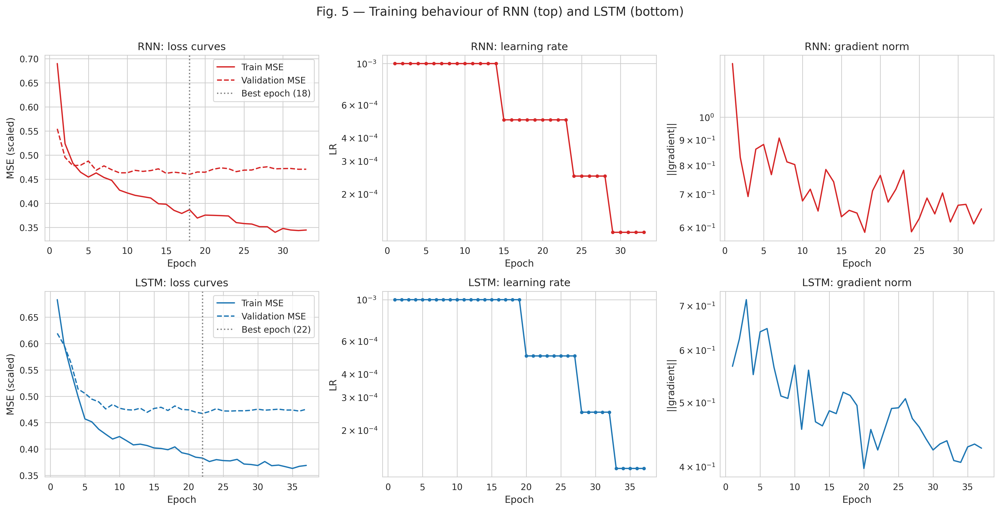

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for r, kind in enumerate(['RNN', 'LSTM']):
    h = results[kind]['hist']; c = C_RNN if kind == 'RNN' else C_LSTM
    ep = np.arange(1, len(h['loss']) + 1)
    best = int(np.argmin(h['val_mse'])) + 1
    ax = axes[r, 0]
    ax.plot(ep, h['mse'], color=c, label='Train MSE')
    ax.plot(ep, h['val_mse'], color=c, ls='--', label='Validation MSE')
    ax.axvline(best, color='gray', ls=':', label=f'Best epoch ({best})')
    ax.set_title(f'{kind}: loss curves'); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled)'); ax.legend()
    ax = axes[r, 1]
    if 'learning_rate' in h: ax.plot(ep, h['learning_rate'], color=c, marker='o', ms=3)
    ax.set_yscale('log'); ax.set_title(f'{kind}: learning rate'); ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax = axes[r, 2]
    ax.plot(np.arange(1, len(results[kind]['gnorms']) + 1), results[kind]['gnorms'], color=c)
    ax.set_yscale('log'); ax.set_title(f'{kind}: gradient norm'); ax.set_xlabel('Epoch'); ax.set_ylabel('||gradient||')
plt.suptitle('Fig. 5 — Training behaviour of RNN (top) and LSTM (bottom)', y=1.01, fontsize=14)
plt.tight_layout(); save_fig('fig05_training_curves'); plt.show()

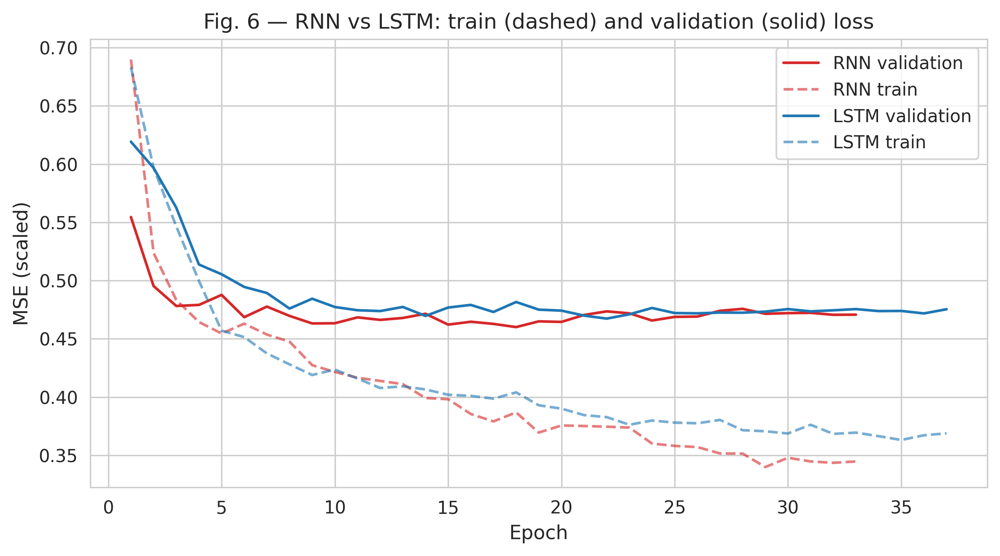

In [40]:
# Direct comparison of the validation curves of both models
plt.figure(figsize=(8, 4.5))
for kind, c in [('RNN', C_RNN), ('LSTM', C_LSTM)]:
    h = results[kind]['hist']
    plt.plot(np.arange(1, len(h['val_mse']) + 1), h['val_mse'], color=c, label=f'{kind} validation')
    plt.plot(np.arange(1, len(h['mse']) + 1), h['mse'], color=c, ls='--', alpha=0.6, label=f'{kind} train')
plt.xlabel('Epoch'); plt.ylabel('MSE (scaled)'); plt.legend()
plt.title('Fig. 6 — RNN vs LSTM: train (dashed) and validation (solid) loss')
plt.tight_layout(); save_fig('fig06_rnn_vs_lstm_loss'); plt.show()

### 8.2 Metrics (original units, kWh/m²/day)
The assignment's report template lists Accuracy/Precision/Recall/F1, which are for **classification**. Ours is **regression**, so we use the regression equivalents:
* **RMSE** – typical error size (punishes big errors) — lower is better
* **MAE** – average absolute error — lower is better
* **R²** – fraction of variance explained (1 = perfect, 0 = as bad as predicting the average) — higher is better
* **MAPE** – average percentage error (days with very low GHI are excluded to avoid dividing by ~0)

**Persistence baseline** = "tomorrow will be the same as today". Any useful model must beat this.

In [41]:
def mape_score(y_true, y_pred, eps=0.1):
    m = np.abs(y_true) > eps
    return np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100

def get_metrics(y_true, y_pred):
    return {'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE' : mean_absolute_error(y_true, y_pred),
            'R2'  : r2_score(y_true, y_pred),
            'MAPE (%)': mape_score(y_true, y_pred)}

def predict_raw(model, X):
    """Predict and convert back to kWh/m2/day."""
    return y_scaler.inverse_transform(model.predict(X, verbose=0)).ravel()

preds = {}   # preds[model][split] = predictions in original units
for kind in ['RNN', 'LSTM']:
    preds[kind] = {s: predict_raw(results[kind]['model'], data[s][0]) for s in ['train', 'val', 'test']}
preds['Persistence'] = {s: ghi_raw[data[s][2] - 1] for s in ['train', 'val', 'test']}   # yesterday's GHI
truth = {s: ghi_raw[data[s][2]] for s in ['train', 'val', 'test']}

rows = []
for mname in ['Persistence', 'RNN', 'LSTM']:
    for s in ['train', 'val', 'test']:
        rows.append({'Model': mname, 'Set': s, **get_metrics(truth[s], preds[mname][s])})
metrics_df = pd.DataFrame(rows)

print('Full results table (use this for Section 6 of the report):')
display(metrics_df.round(4))

print('\nTest-set comparison:')
test_tab = metrics_df[metrics_df.Set == 'test'].set_index('Model').drop(columns='Set').round(4)
display(test_tab)

Full results table (use this for Section 6 of the report):


,Model,Set,RMSE,MAE,R2,MAPE (%)
0,Persistence,train,0.9526,0.6736,0.4272,18.1447
1,Persistence,val,1.0348,0.7197,0.2764,20.7171
2,Persistence,test,1.0270,0.7288,0.4036,21.0973
3,RNN,train,0.7254,0.5416,0.6678,15.4069
4,RNN,val,0.8542,0.6165,0.5068,18.7133
5,RNN,test,0.8777,0.6499,0.5644,20.5139
6,LSTM,train,0.7549,0.5614,0.6403,15.8633
7,LSTM,val,0.8610,0.6105,0.4990,18.9055
8,LSTM,test,0.8518,0.6243,0.5897,19.7352



Test-set comparison:


,RMSE,MAE,R2,MAPE (%)
Model,,,,
Persistence,1.0270,0.7288,0.4036,21.0973
RNN,0.8777,0.6499,0.5644,20.5139
LSTM,0.8518,0.6243,0.5897,19.7352


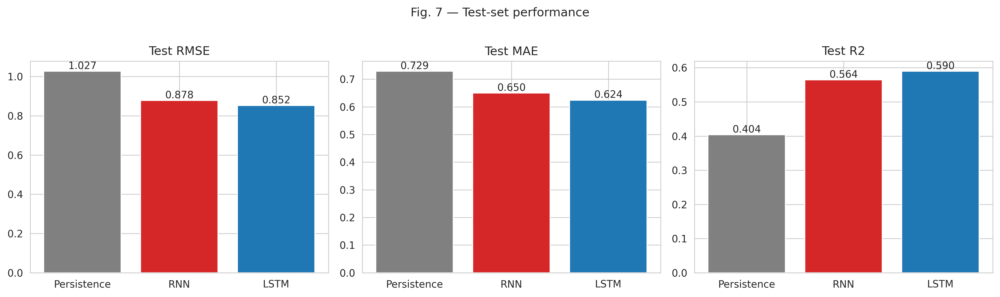

In [42]:
# Figure 7 - bar chart of the test metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['gray', C_RNN, C_LSTM]
for ax, m in zip(axes, ['RMSE', 'MAE', 'R2']):
    vals = test_tab[m]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(f'Test {m}'); ax.bar_label(bars, fmt='%.3f')
plt.suptitle('Fig. 7 — Test-set performance', y=1.02)
plt.tight_layout(); save_fig('fig07_test_metrics'); plt.show()

### 8.3 Predictions vs reality (test set)

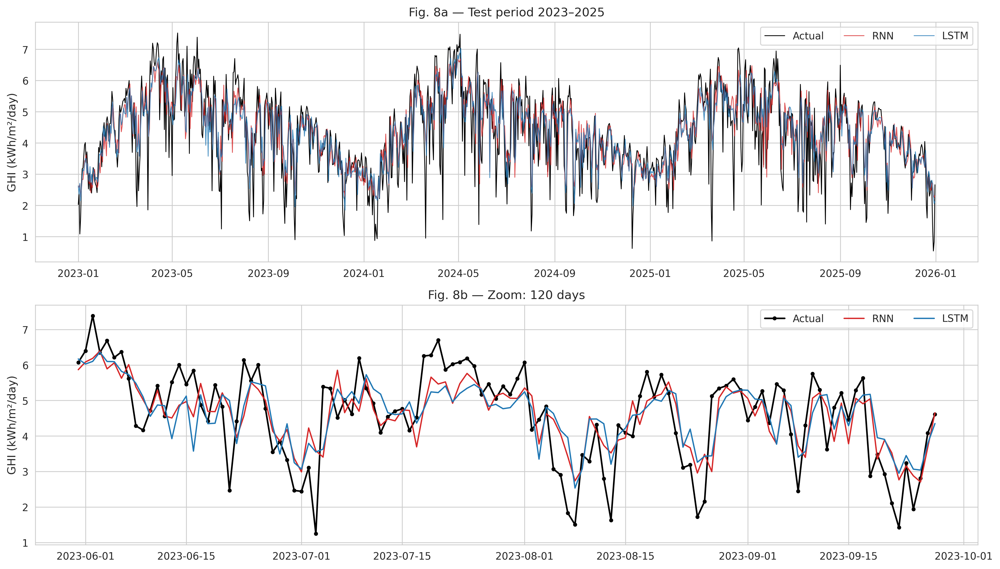

In [43]:
test_dates = df.index[idx_test]
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
# (a) the whole test period
axes[0].plot(test_dates, truth['test'], color=C_TRUE, lw=0.8, label='Actual')
axes[0].plot(test_dates, preds['RNN']['test'],  color=C_RNN,  lw=0.8, alpha=0.8, label='RNN')
axes[0].plot(test_dates, preds['LSTM']['test'], color=C_LSTM, lw=0.8, alpha=0.8, label='LSTM')
axes[0].set_title('Fig. 8a — Test period 2023–2025'); axes[0].set_ylabel('GHI (kWh/m²/day)'); axes[0].legend(ncol=3)
# (b) zoom on 120 days
sl = slice(150, 270)
axes[1].plot(test_dates[sl], truth['test'][sl], color=C_TRUE, lw=1.6, marker='o', ms=3, label='Actual')
axes[1].plot(test_dates[sl], preds['RNN']['test'][sl],  color=C_RNN,  lw=1.3, label='RNN')
axes[1].plot(test_dates[sl], preds['LSTM']['test'][sl], color=C_LSTM, lw=1.3, label='LSTM')
axes[1].set_title('Fig. 8b — Zoom: 120 days'); axes[1].set_ylabel('GHI (kWh/m²/day)'); axes[1].legend(ncol=3)
plt.tight_layout(); save_fig('fig08_predictions'); plt.show()

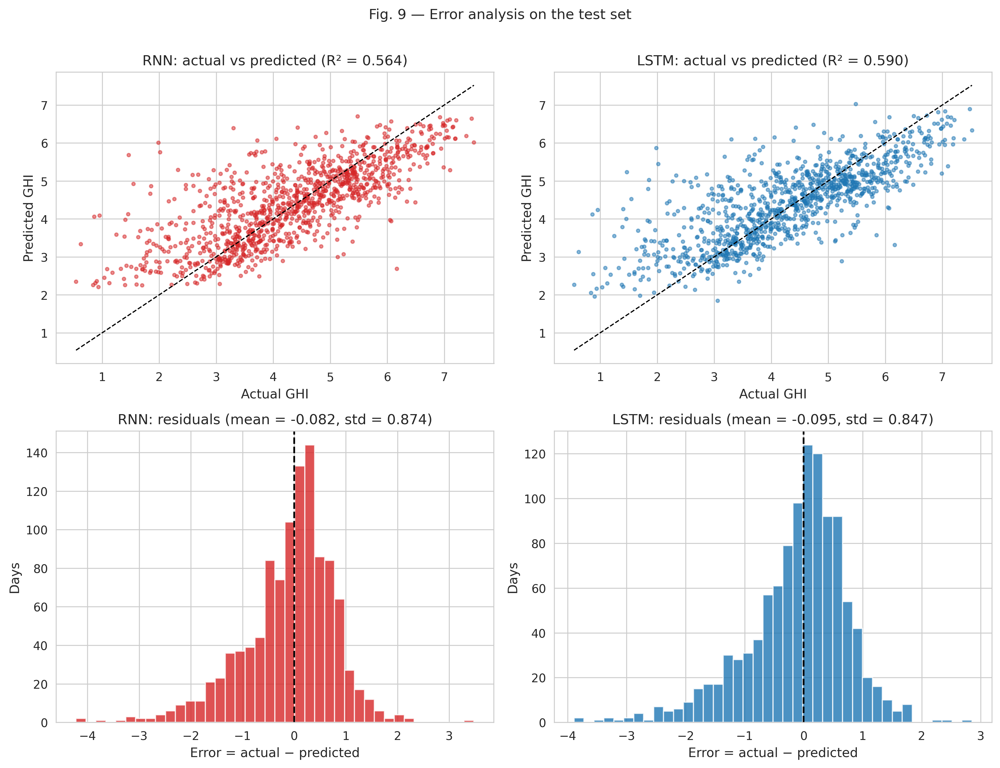

In [44]:
# Figure 9 - actual vs predicted scatter + residual histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for c_idx, kind in enumerate(['RNN', 'LSTM']):
    c = C_RNN if kind == 'RNN' else C_LSTM
    yt, yp = truth['test'], preds[kind]['test']
    ax = axes[0, c_idx]
    ax.scatter(yt, yp, s=8, alpha=0.5, color=c)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel('Actual GHI'); ax.set_ylabel('Predicted GHI')
    ax.set_title(f'{kind}: actual vs predicted (R² = {r2_score(yt, yp):.3f})')
    ax = axes[1, c_idx]
    res = yt - yp
    ax.hist(res, bins=40, color=c, alpha=0.8)
    ax.axvline(0, color='k', ls='--')
    ax.set_xlabel('Error = actual − predicted'); ax.set_ylabel('Days')
    ax.set_title(f'{kind}: residuals (mean = {res.mean():.3f}, std = {res.std():.3f})')
plt.suptitle('Fig. 9 — Error analysis on the test set', y=1.01)
plt.tight_layout(); save_fig('fig09_scatter_residuals'); plt.show()

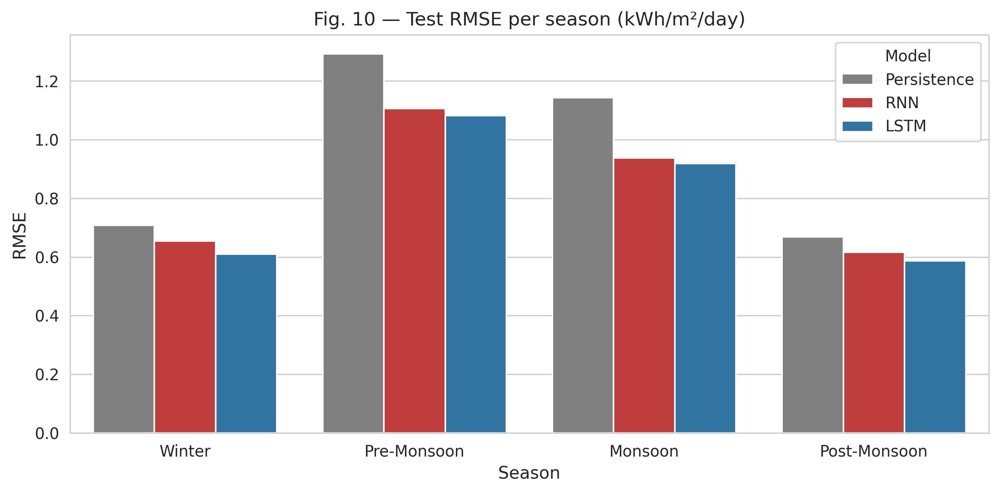

Model,LSTM,Persistence,RNN
Season,,,
Winter,0.610,0.707,0.655
Pre-Monsoon,1.081,1.292,1.105
Monsoon,0.918,1.142,0.937
Post-Monsoon,0.587,0.668,0.616


In [45]:
# Figure 10 - which season is hardest to predict?
seasons_test = np.array([get_season(m) for m in test_dates.month])
rows = []
for mname in ['Persistence', 'RNN', 'LSTM']:
    for s in SEASONS:
        mask = seasons_test == s
        rows.append({'Model': mname, 'Season': s,
                     'RMSE': np.sqrt(mean_squared_error(truth['test'][mask], preds[mname]['test'][mask]))})
season_df = pd.DataFrame(rows)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=season_df, x='Season', y='RMSE', hue='Model', order=SEASONS,
            palette=['gray', C_RNN, C_LSTM])
plt.title('Fig. 10 — Test RMSE per season (kWh/m²/day)')
plt.tight_layout(); save_fig('fig10_season_error'); plt.show()
display(season_df.pivot(index='Season', columns='Model', values='RMSE').loc[SEASONS].round(3))

## 🔬 Section 9: Does Regularization Help? (Ablation Study)

The assignment asks us to *analyse the impact* of the regularization techniques. An **ablation study** trains the same LSTM several times, switching techniques on/off one at a time.

For a fair picture, **early stopping is switched off** here and every run trains for exactly 40 epochs (15 if `QUICK_RUN = True`). (Early stopping alone already prevents over-fitting and would hide the effect of the other techniques.)

| Run | L2 | Dropout | LR scheduler |
|---|---|---|---|
| 1. None | ✗ | ✗ | ✗ |
| 2. L2 only | ✓ | ✗ | ✗ |
| 3. Dropout only | ✗ | ✓ | ✗ |
| 4. Scheduler only | ✗ | ✗ | ✓ |
| 5. L2 + Dropout | ✓ | ✓ | ✗ |
| 6. L2 + Dropout + Scheduler | ✓ | ✓ | ✓ |

In [46]:
ABL_EPOCHS = 15 if QUICK_RUN else 40
ablation_cfg = {
    '1. None'                    : dict(l2=0,         dropout=0,       use_scheduler=False),
    '2. L2 only'                 : dict(l2=L2_LAMBDA, dropout=0,       use_scheduler=False),
    '3. Dropout only'            : dict(l2=0,         dropout=DROPOUT, use_scheduler=False),
    '4. Scheduler only'          : dict(l2=0,         dropout=0,       use_scheduler=True),
    '5. L2 + Dropout'            : dict(l2=L2_LAMBDA, dropout=DROPOUT, use_scheduler=False),
    '6. L2 + Dropout + Scheduler': dict(l2=L2_LAMBDA, dropout=DROPOUT, use_scheduler=True),
}
abl_hist, abl_rows = {}, []
for name, cfg in ablation_cfg.items():
    print('Training:', name)
    m, h, _, secs = train_model('LSTM', data, use_early_stopping=False, epochs=ABL_EPOCHS, **cfg)
    abl_hist[name] = h
    p_tr = predict_raw(m, data['train'][0]); p_va = predict_raw(m, data['val'][0]); p_te = predict_raw(m, data['test'][0])
    abl_rows.append({'Configuration': name,
                     'Train RMSE': get_metrics(truth['train'], p_tr)['RMSE'],
                     'Val RMSE'  : get_metrics(truth['val'],   p_va)['RMSE'],
                     'Test RMSE' : get_metrics(truth['test'],  p_te)['RMSE'],
                     'Test R2'   : get_metrics(truth['test'],  p_te)['R2'],
                     'Gap (Val - Train)': get_metrics(truth['val'], p_va)['RMSE'] - get_metrics(truth['train'], p_tr)['RMSE']})
ablation_df = pd.DataFrame(abl_rows).set_index('Configuration')
print('\nAblation results (LSTM, 40 epochs, no early stopping):')
display(ablation_df.round(4))

Training: 1. None
Training: 2. L2 only
Training: 3. Dropout only
Training: 4. Scheduler only
Training: 5. L2 + Dropout
Training: 6. L2 + Dropout + Scheduler

Ablation results (LSTM, 40 epochs, no early stopping):


,Train RMSE,Val RMSE,Test RMSE,Test R2,Gap (Val - Train)
Configuration,,,,,
1. None,0.6235,0.9616,0.9880,0.4480,0.3382
2. L2 only,0.6433,0.9715,0.9773,0.4599,0.3281
3. Dropout only,0.6881,0.8721,0.9071,0.5348,0.1841
4. Scheduler only,0.7111,0.8751,0.8673,0.5747,0.1640
5. L2 + Dropout,0.7235,0.8727,0.8926,0.5495,0.1492
6. L2 + Dropout + Scheduler,0.7357,0.8689,0.8604,0.5814,0.1331


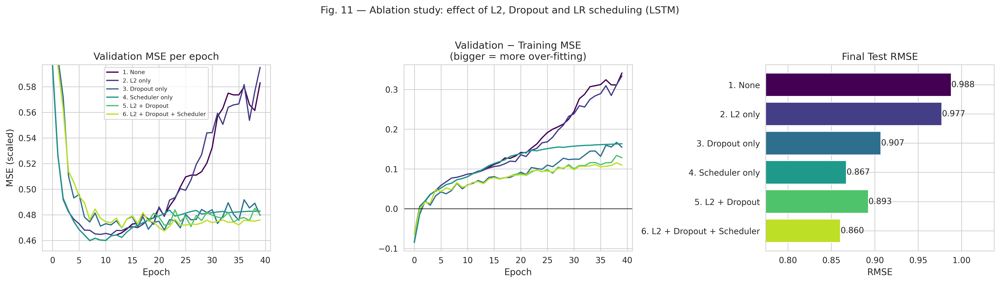

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
cols_abl = plt.cm.viridis(np.linspace(0, 0.9, len(abl_hist)))
for (name, h), c in zip(abl_hist.items(), cols_abl):
    axes[0].plot(h['val_mse'], color=c, label=name)
    axes[1].plot(np.array(h['val_mse']) - np.array(h['mse']), color=c, label=name)
axes[0].set_title('Validation MSE per epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (scaled)')
axes[0].set_ylim(top=np.percentile(np.concatenate([h['val_mse'] for h in abl_hist.values()]), 98))
axes[0].legend(fontsize=7)
axes[1].axhline(0, color='k', lw=0.7)
axes[1].set_title('Validation − Training MSE\n(bigger = more over-fitting)'); axes[1].set_xlabel('Epoch')
bars = axes[2].barh(ablation_df.index[::-1], ablation_df['Test RMSE'][::-1], color=cols_abl[::-1])
axes[2].bar_label(bars, fmt='%.3f'); axes[2].set_title('Final Test RMSE'); axes[2].set_xlabel('RMSE')
axes[2].set_xlim(left=ablation_df['Test RMSE'].min() * 0.9)
plt.suptitle('Fig. 11 — Ablation study: effect of L2, Dropout and LR scheduling (LSTM)', y=1.03)
plt.tight_layout(); save_fig('fig11_ablation'); plt.show()

**How to read the ablation (write this in the Discussion):**
* Compare run 1 (no regularization) with runs 2, 3 and 5: does the validation/test RMSE go down? Does the gap between training and validation shrink?
* Run 4 vs run 1 shows what the scheduler alone does; run 6 vs run 5 shows what it adds on top of L2 + dropout.
* With a **small dataset and a low-noise target like this one, the differences can be small** (e.g. 0.01–0.05 RMSE). That is a valid finding — report the numbers honestly, even if one technique does not help much.

## 🧠 Section 10: Critical Analysis — Vanishing / Exploding Gradients and RNN vs LSTM

**Question:** can the network still "feel" what happened many days ago?

**Experiment.** For a trained model we measure how strongly the prediction reacts to a small change in the input of each past day, i.e. the size of $\partial\hat y/\partial x_t$ (averaged over the test samples).
* If the sensitivity to *old* days is tiny compared with *recent* days → the gradient **vanishes** over time (the model has a short memory).
* A longer window makes the problem harder, so we repeat the experiment for windows of **7, 30 and 60 days** and train a fresh RNN and LSTM for each.

*(Gradient-clipping and early stopping stay on, as in the main experiment.)*

In [48]:
def gradient_profile(model, X):
    """Average |d prediction / d input_t| for every time step t of the window."""
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        y = model(x, training=False)
    g = tape.gradient(y, x)                 # (samples, window, features)
    g = tf.norm(g, axis=2)                  # size over the features -> (samples, window)
    return tf.reduce_mean(g, axis=0).numpy()

WINDOWS = [7, 30] if QUICK_RUN else [7, 30, 60]
WIN_EPOCHS = 30 if QUICK_RUN else 60
win_res = {}
for w in WINDOWS:
    dw = split_windows(w)
    for kind in ['RNN', 'LSTM']:
        print(f'Window = {w:2d} days | training {kind} ...')
        m, h, gn, secs = train_model(kind, dw, window=w, epochs=WIN_EPOCHS)
        prof = gradient_profile(m, dw['test'][0])
        p_te = predict_raw(m, dw['test'][0])
        win_res[(w, kind)] = dict(profile=prof, test_rmse=get_metrics(ghi_raw[dw['test'][2]], p_te)['RMSE'],
                                  epochs=len(h['loss']), max_gn=max(gn), model=m)
print('Done.')

Window =  7 days | training RNN ...
Window =  7 days | training LSTM ...
Window = 30 days | training RNN ...
Window = 30 days | training LSTM ...
Window = 60 days | training RNN ...
Window = 60 days | training LSTM ...
Done.


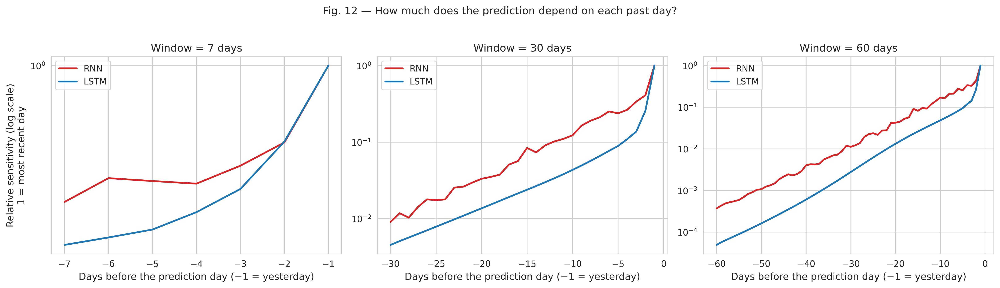

,Window (days),Model,Sensitivity oldest / newest day,Test RMSE,Epochs run,Largest gradient norm
0,7,RNN,0.19746,0.87131,29,0.86787
1,7,LSTM,0.11854,0.84414,48,0.62061
2,30,RNN,0.00907,0.87860,22,0.83171
3,30,LSTM,0.00455,0.85629,30,0.50526
4,60,RNN,0.00037,0.86856,28,0.99929
5,60,LSTM,0.00005,0.85704,30,0.43648


In [49]:
# Figure 12 - gradient / sensitivity profile
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, w in zip(axes, WINDOWS):
    for kind, c in [('RNN', C_RNN), ('LSTM', C_LSTM)]:
        prof = win_res[(w, kind)]['profile']
        prof = prof / prof[-1]                           # 1.0 = most recent day
        ax.plot(np.arange(-w, 0), prof, color=c, lw=2, label=kind)
    ax.set_yscale('log'); ax.set_xlabel('Days before the prediction day (−1 = yesterday)')
    ax.set_title(f'Window = {w} days'); ax.legend()
axes[0].set_ylabel('Relative sensitivity (log scale)\n1 = most recent day')
plt.suptitle('Fig. 12 — How much does the prediction depend on each past day?', y=1.03)
plt.tight_layout(); save_fig('fig12_gradient_profile'); plt.show()

# Summary table: how much of the "signal" reaches the oldest day?
rows = []
for w in WINDOWS:
    for kind in ['RNN', 'LSTM']:
        r = win_res[(w, kind)]; p = r['profile']
        rows.append({'Window (days)': w, 'Model': kind,
                     'Sensitivity oldest / newest day': p[0] / p[-1],
                     'Test RMSE': r['test_rmse'], 'Epochs run': r['epochs'],
                     'Largest gradient norm': r['max_gn']})
window_df = pd.DataFrame(rows)
display(window_df.round(5))

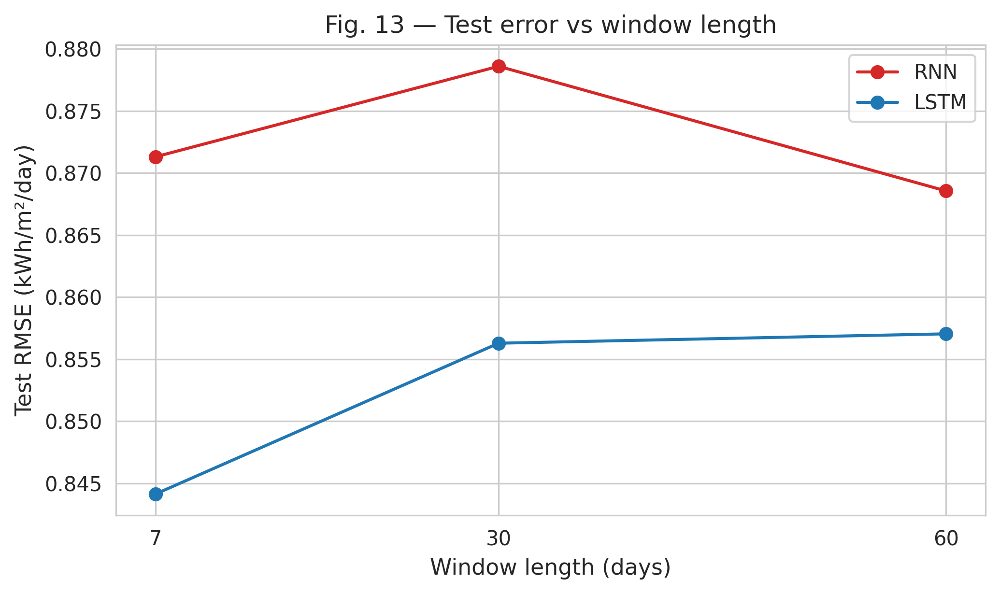

In [50]:
# Figure 13 - does a longer window help or hurt each model?
fig, ax = plt.subplots(figsize=(7, 4.2))
for kind, c in [('RNN', C_RNN), ('LSTM', C_LSTM)]:
    d = window_df[window_df.Model == kind]
    ax.plot(d['Window (days)'], d['Test RMSE'], marker='o', color=c, label=kind)
ax.set_xticks(WINDOWS); ax.set_xlabel('Window length (days)'); ax.set_ylabel('Test RMSE (kWh/m²/day)')
ax.set_title('Fig. 13 — Test error vs window length'); ax.legend()
plt.tight_layout(); save_fig('fig13_window_vs_rmse'); plt.show()

### How to interpret Figs. 5 (right), 12 and 13 (use in your Discussion)
* **Fig. 12:** a curve that drops sharply to the left (old days) means vanishing gradients. The ratio "oldest / newest" in the table quantifies it. A smaller ratio = more vanishing. Compare RNN with LSTM, and look at how the ratio changes with the window length.
* **Fig. 5 (right) and the "largest gradient norm" column:** sudden spikes or huge values would indicate exploding gradients. Because we use `clipnorm = 1.0`, the *update* is capped anyway — so if you see no explosion, say that clipping and the bounded `tanh` activation helped.
* **Fig. 13:** if the RNN gets worse for long windows while the LSTM stays stable or improves, that supports the vanishing-gradient explanation. If both behave similarly, that is also a legitimate result: **for next-day solar forecasting most of the useful information is in the last few days**, so the long-memory advantage of the LSTM is small.
* Be honest: report what you actually observe. A short window (14 days) may simply not be long enough for the RNN to suffer much.

## 🌍 Section 11: Real-Life Application Perspective

**Why next-day solar forecasting matters.** Solar output is *variable* — clouds, humidity and the monsoon change it every day. A reliable day-ahead forecast of irradiance lets utilities and plant owners plan with confidence.

| Application | How the forecast helps |
|---|---|
| **Grid operation** (e.g. BPDB / national grid) | Decide how much conventional (gas/coal) generation to schedule for tomorrow, reducing fuel cost and avoiding blackouts when solar drops. |
| **Solar PV plants & rooftop systems** | Estimate tomorrow's energy yield → energy trading, maintenance planning, grid-connection commitments. |
| **Battery storage / off-grid & microgrids** | Charge or discharge batteries wisely; important for rural solar home systems in Bangladesh. |
| **Solar irrigation pumps (agriculture)** | Schedule pumping on the sunniest hours/days. |
| **Smart buildings** | Shift flexible loads (water heating, EV charging) to the expected sunny periods. |
| **Policy & planning** | Site assessment for new solar parks and national renewable targets (SDG 7 – clean energy, SDG 13 – climate action). |

**How our system would be deployed:** every morning, download yesterday's weather data → scale it with the stored scalers → feed the last 14 days to the trained LSTM → get tomorrow's GHI → convert it to expected PV power (GHI × panel area × efficiency) for the dispatch plan.

**Limitations to mention (honest discussion):** the model uses *daily satellite/reanalysis data* for one location; real systems would add hourly data, satellite cloud images or numerical weather-prediction inputs, and would be re-trained regularly. The model gives a single value (no uncertainty range) — real planning also needs prediction intervals.

## 📋 Section 12: Summary Tables for the Report and Download of All Figures

In [51]:
# ---- Report Section 5: hyperparameters table
hp = pd.DataFrame({
    'Hyperparameter': ['Learning rate (initial)', 'Optimizer', 'Batch size', 'Loss function',
                       'Epochs (max)', 'Activation', 'Framework', 'Random seed',
                       'Window length', 'Recurrent units', 'Dropout rate', 'L2 lambda',
                       'LR scheduler', 'Early stopping', 'Gradient clipping'],
    'Value': [LR, 'Adam (beta1=0.9, beta2=0.999)', BATCH_SIZE, 'MSE (+ L2 penalty)',
              f'{MAX_EPOCHS} (early stopping)', 'tanh (recurrent), ReLU (dense), linear (output)',
              f'TensorFlow {tf.__version__} / Keras', SEED,
              f'{WINDOW} days', f'{UNITS_1} -> {UNITS_2}', DROPOUT, L2_LAMBDA,
              f'ReduceLROnPlateau (factor {LR_FACTOR}, patience {LR_PATIENCE}, min {MIN_LR})',
              f'patience {ES_PATIENCE}, restore best weights', f'clipnorm = {CLIPNORM}']})
print('Hyperparameters (Report Section 5):'); display(hp)

# ---- Report Section 3: dataset table
ds = pd.DataFrame({'Item': ['Dataset', 'Location', 'Period', 'No. of days', 'Input features', 'Target',
                            'Split (chronological)', 'Preprocessing'],
                   'Value': ['NASA POWER daily data', 'RUET, Rajshahi (24.3641N, 88.63E)',
                             f'{df.index[0].date()} to {df.index[-1].date()}', len(df),
                             f'{N_FEATURES}: ' + ', '.join(FEATURES),
                             'GHI of the next day (kWh/m2/day)',
                             f'Train {len(idx_train)} / Val {len(idx_val)} / Test {len(idx_test)} samples (60/20/20)',
                             '-999 -> interpolation; standardisation (fit on train only); sin/cos day-of-year; '
                             f'{WINDOW}-day sliding windows']})
print('\nDataset description (Report Section 3):'); display(ds)

print('\nMetrics table (Report Section 6): see metrics_df')
display(metrics_df.pivot(index='Model', columns='Set', values='RMSE').round(4).rename_axis(columns='RMSE'))
display(metrics_df.pivot(index='Model', columns='Set', values='R2').round(4).rename_axis(columns='R2'))

# ---- save all tables to CSV
for nm, t in [('metrics', metrics_df), ('ablation', ablation_df.reset_index()),
              ('window_gradient_experiment', window_df), ('hyperparameters', hp), ('dataset', ds)]:
    t.to_csv(f'figures/table_{nm}.csv', index=False)

Hyperparameters (Report Section 5):


,Hyperparameter,Value
0,Learning rate (initial),0.001
1,Optimizer,"Adam (beta1=0.9, beta2=0.999)"
2,Batch size,32
3,Loss function,MSE (+ L2 penalty)
4,Epochs (max),100 (early stopping)
5,Activation,"tanh (recurrent), ReLU (dense), linear (output)"
6,Framework,TensorFlow 2.21.0 / Keras
7,Random seed,42
8,Window length,14 days
9,Recurrent units,64 -> 32



Dataset description (Report Section 3):


,Item,Value
0,Dataset,NASA POWER daily data
1,Location,"RUET, Rajshahi (24.3641N, 88.63E)"
2,Period,2011-01-01 to 2025-12-31
3,No. of days,5479
4,Input features,"7: GHI, Temperature, Humidity, WindSpeed, Prec..."
5,Target,GHI of the next day (kWh/m2/day)
6,Split (chronological),Train 3273 / Val 1096 / Test 1096 samples (60/...
7,Preprocessing,-999 -> interpolation; standardisation (fit on...



Metrics table (Report Section 6): see metrics_df


RMSE,test,train,val
Model,,,
LSTM,0.8518,0.7549,0.8610
Persistence,1.0270,0.9526,1.0348
RNN,0.8777,0.7254,0.8542


R2,test,train,val
Model,,,
LSTM,0.5897,0.6403,0.4990
Persistence,0.4036,0.4272,0.2764
RNN,0.5644,0.6678,0.5068


In [52]:
# ---- Zip everything (figures + tables) and download
with zipfile.ZipFile('assignment_outputs.zip', 'w') as z:
    for f in sorted(os.listdir('figures')):
        z.write(os.path.join('figures', f))
print('Files in the zip:'); print('\n'.join(sorted(os.listdir('figures'))))
files.download('assignment_outputs.zip')

Files in the zip:
fig01_timeseries.png
fig02_monthly_seasonal.png
fig03_correlation.png
fig04_split.png
fig05_training_curves.png
fig06_rnn_vs_lstm_loss.png
fig07_test_metrics.png
fig08_predictions.png
fig09_scatter_residuals.png
fig10_season_error.png
fig11_ablation.png
fig12_gradient_profile.png
fig13_window_vs_rmse.png
table_ablation.csv
table_dataset.csv
table_hyperparameters.csv
table_metrics.csv
table_window_gradient_experiment.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## ✅ Checklist before you submit
- [ ] Fill in the header of the report (name, roll, section, etc.).
- [ ] Section 4.1/4.2 of the report: copy from Section 5 of this notebook (model choice + architecture table).
- [ ] Section 5.1: paste `build_model` and the `train_model` function as the key code.
- [ ] Section 6: use the metrics tables and Figs. 5–10 (replace Accuracy/Precision/Recall/F1 with RMSE/MAE/R²/MAPE and say why).
- [ ] Section 7 (Discussion): use Fig. 11 (regularization), Fig. 12–13 and Fig. 5 (gradients), Fig. 10 (seasonal errors).
- [ ] Mathematical explanation (Section 6 of this notebook), RNN vs LSTM comparison (Sections 8 and 10) and application (Section 11).
- [ ] Write your own conclusions from the numbers that **your** run produced — they will differ slightly from run to run.